# Analyzing Molecular Features and Neuron Similarity in C. elegans

This notebook demonstrates how to compute and analyze neuron similarity across multiple dimensions:
1. **Sensory Type** - Which sensory modalities neurons respond to
2. **Anatomical Process** - Where neurons have physical processes
3. **NT/NPP Release** - Which neurotransmitters/neuropeptides neurons release
4. **NT/NPP Receptor** - Which receptors neurons express

In [1]:
import sys
sys.path.insert(0, '../src')

import pub_utils as pu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"pub_utils version: {pu.__version__}")
print(f"Number of neurons: {len(pu.AllHermNeurons)}")

pub_utils version: 0.1.0
Number of neurons: 302


## 1. Load Pre-computed Similarity Matrices

Pre-computed similarity matrices are available in `connectomes/similarity/`.

In [2]:
# Load pre-computed similarity matrices
sensory_sim = pd.read_csv('../connectomes/similarity/sensory_similarity.csv', index_col=0)
process_sim = pd.read_csv('../connectomes/similarity/process_similarity.csv', index_col=0)
release_sim = pd.read_csv('../connectomes/similarity/release_similarity.csv', index_col=0)
receptor_sim = pd.read_csv('../connectomes/similarity/receptor_similarity.csv', index_col=0)

print("Loaded similarity matrices:")
print(f"  Sensory: {sensory_sim.shape}")
print(f"  Process: {process_sim.shape}")
print(f"  Release: {release_sim.shape}")
print(f"  Receptor: {receptor_sim.shape}")

Loaded similarity matrices:
  Sensory: (302, 302)
  Process: (302, 302)
  Release: (302, 302)
  Receptor: (302, 302)


## 2. Explore Feature Profiles

Let's look at the underlying feature profiles used to compute similarity.

In [3]:
# Get sensory type profile
sensory_profile = pu.get_sensory_profile()
print("Sensory Types (13 modalities):")
print(sensory_profile.columns.tolist())
print(f"\nShape: {sensory_profile.shape}")

Sensory Types (13 modalities):
['chemical', 'odor', 'pheromone', 'osmolarity', 'oxygen', 'carbon_dioxide', 'photon', 'thermal', 'electrical', 'mechanical', 'stretch', 'nociceptive']

Shape: (302, 12)


In [4]:
# Get anatomical process profile
process_profile = pu.get_process_profile()
print("Anatomical Process Locations:")
print(process_profile.columns.tolist())
print(f"\nShape: {process_profile.shape}")

Anatomical Process Locations:
['amphid_commissure_left', 'amphid_commissure_right', 'anterior_subdorsal_cord_left', 'anterior_subdorsal_cord_right', 'anterior_subventral_cord_left', 'anterior_subventral_cord_right', 'anterior_to_nerve_ring', 'canal_associated_left', 'canal_associated_right', 'canal_associated_tail', 'deirid_commissure_left', 'deirid_commissure_right', 'dorsal_cord', 'dorsal_sublateral_left', 'dorsal_sublateral_right', 'labial_sensory_dorsal_left', 'labial_sensory_dorsal_right', 'labial_sensory_left', 'labial_sensory_right', 'labial_sensory_ventral_left', 'labial_sensory_ventral_right', 'nerve_ring', 'pharynx', 'tail_preanal_ganglion', 'tail_tip', 'ventral_cord', 'ventral_retrovesicular_ganglion', 'ventral_sublateral_left', 'ventral_sublateral_right']

Shape: (302, 29)


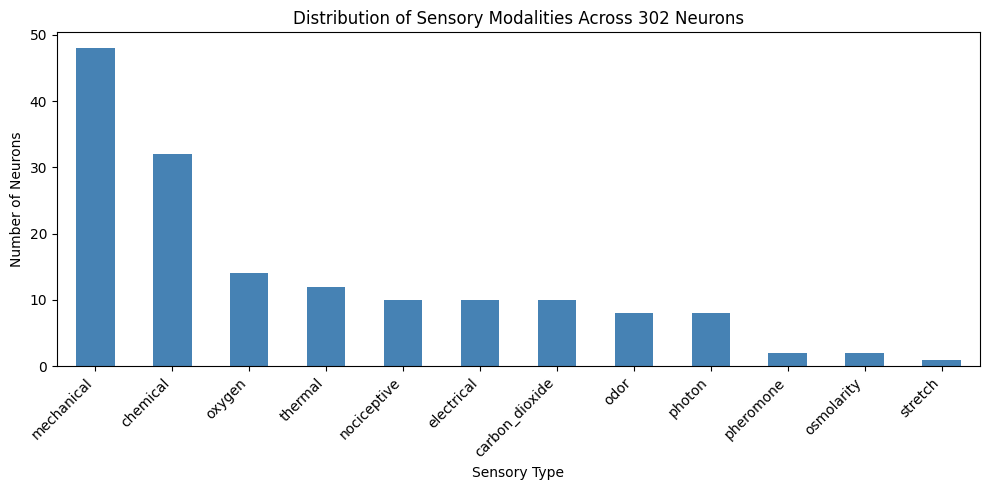

In [5]:
# Count neurons per sensory type
sensory_counts = sensory_profile.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sensory_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Sensory Type')
ax.set_ylabel('Number of Neurons')
ax.set_title('Distribution of Sensory Modalities Across 302 Neurons')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Compute Similarity On-the-Fly

You can also compute similarity matrices dynamically using the API.

In [6]:
# Compute sensory similarity with metadata
result = pu.compute_sensory_similarity(metric='jaccard')

print("Result keys:", result.keys())
print(f"\nMetadata: {result['metadata']}")
print(f"\nSimilarity matrix shape: {result['similarity'].shape}")
print(f"Profile matrix shape: {result['profile'].shape}")

Result keys: dict_keys(['similarity', 'profile', 'metadata'])

Metadata: {'metric': 'jaccard', 'n_features': 12, 'feature_names': ['chemical', 'odor', 'pheromone', 'osmolarity', 'oxygen', 'carbon_dioxide', 'photon', 'thermal', 'electrical', 'mechanical', 'stretch', 'nociceptive']}

Similarity matrix shape: (302, 302)
Profile matrix shape: (302, 12)


## 4. Find Similar Neurons

Find neurons most similar to a query neuron across different dimensions.

In [7]:
# Find neurons similar to AVAL (a key command interneuron)
query_neuron = 'AVAL'

print(f"Neurons most similar to {query_neuron}:")
print("\n--- Sensory Similarity ---")
print(pu.find_similar_neurons(sensory_sim, query_neuron, top_n=5))

print("\n--- Process Similarity ---")
print(pu.find_similar_neurons(process_sim, query_neuron, top_n=5))

print("\n--- Release Similarity ---")
print(pu.find_similar_neurons(release_sim, query_neuron, top_n=5))

print("\n--- Receptor Similarity ---")
print(pu.find_similar_neurons(receptor_sim, query_neuron, top_n=5))

Neurons most similar to AVAL:

--- Sensory Similarity ---
  neuron_id  similarity
0      VC06         1.0
1       I1L         1.0
2       I1R         1.0
3       I2L         1.0
4       I2R         1.0

--- Process Similarity ---
  neuron_id  similarity
0      HSNR         1.0
1       AVM         1.0
2      AVAR         1.0
3      AVDR         1.0
4       AVL         1.0

--- Release Similarity ---
  neuron_id  similarity
0      AVAR    1.000000
1      RIGL    0.625000
2      RIGR    0.625000
3      DA05    0.618718
4      DA03    0.618718

--- Receptor Similarity ---
  neuron_id  similarity
0      AVAR    1.000000
1     SMDDR    0.695182
2     SMDDL    0.695182
3     SMDVR    0.654289
4     SMDVL    0.654289


## 5. Compare Neuron Pairs Across Dimensions

Compare similarity between two neurons across all four dimensions.

In [8]:
# Compare ASEL and ASER (bilateral pair)
neuron_a, neuron_b = 'ASEL', 'ASER'

results = {
    'sensory': {'similarity': sensory_sim},
    'process': {'similarity': process_sim},
    'release': {'similarity': release_sim},
    'receptor': {'similarity': receptor_sim}
}

print(f"Similarity between {neuron_a} and {neuron_b}:")
for dim, data in results.items():
    sim = data['similarity'].loc[neuron_a, neuron_b]
    print(f"  {dim:12s}: {sim:.4f}")

Similarity between ASEL and ASER:
  sensory     : 1.0000
  process     : 0.5000
  release     : 0.5379
  receptor    : 0.5963


In [9]:
# Compare multiple neuron pairs
pairs = [
    ('ASEL', 'ASER'),   # Bilateral sensory pair
    ('AVAL', 'AVAR'),   # Bilateral interneuron pair
    ('ASEL', 'AVAL'),   # Different cell types
    ('DA01', 'DA02'),   # Adjacent motor neurons
]

comparison_data = []
for n1, n2 in pairs:
    row = {'pair': f"{n1}-{n2}"}
    for dim, data in results.items():
        row[dim] = data['similarity'].loc[n1, n2]
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('pair', inplace=True)
print(comparison_df.round(3))

           sensory  process  release  receptor
pair                                          
ASEL-ASER      1.0    0.500    0.538     0.596
AVAL-AVAR      1.0    1.000    1.000     1.000
ASEL-AVAL      0.0    0.577    0.200     0.175
DA01-DA02      1.0    1.000    1.000     1.000


## 6. Visualize Similarity Matrices

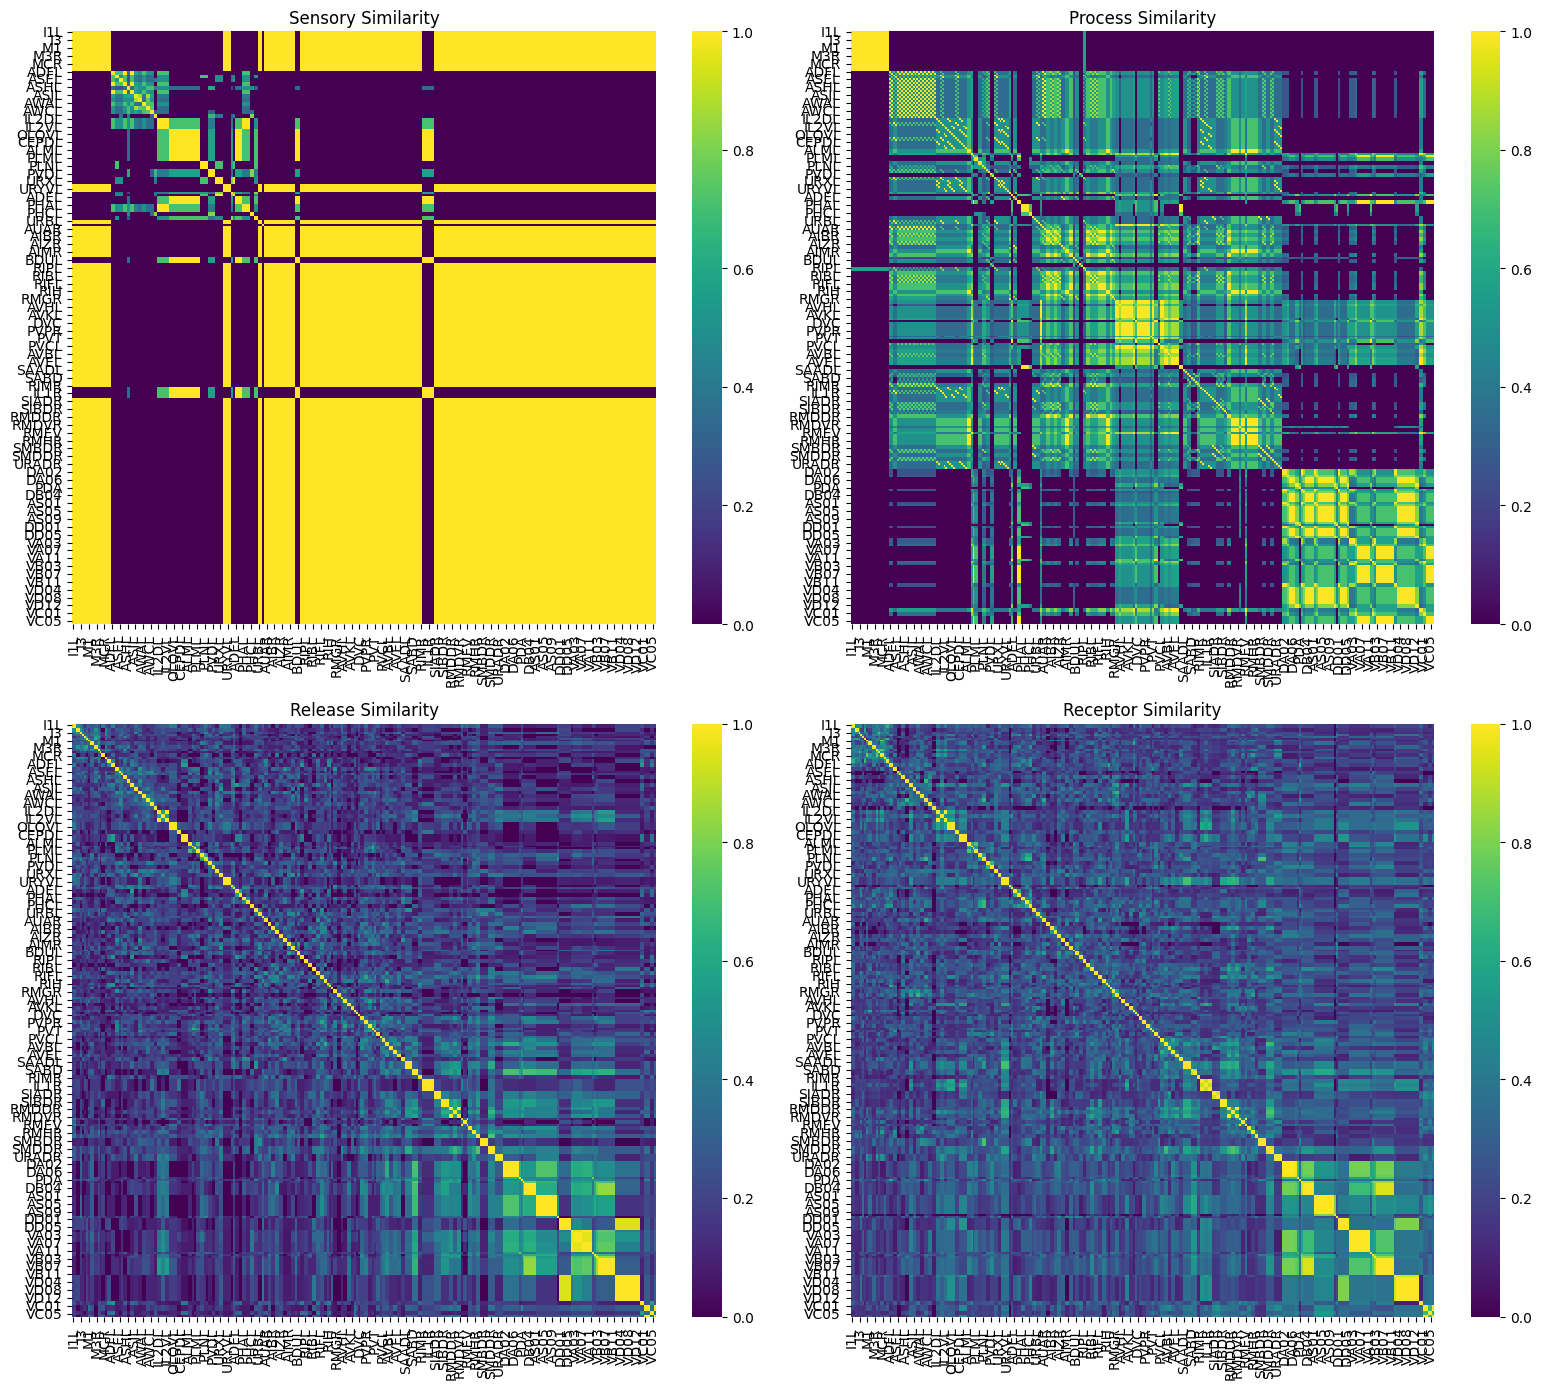

In [10]:
subset = pu.AllHermNeurons

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (title, sim_matrix) in zip(axes.flat, [
    ('Sensory Similarity', sensory_sim),
    ('Process Similarity', process_sim),
    ('Release Similarity', release_sim),
    ('Receptor Similarity', receptor_sim)
]):
    subset_sim = sim_matrix.loc[subset, subset]
    sns.heatmap(subset_sim, ax=ax, cmap='viridis', vmin=0, vmax=1,
                xticklabels=4, yticklabels=4)
    ax.set_title(title)

plt.tight_layout()
plt.show()

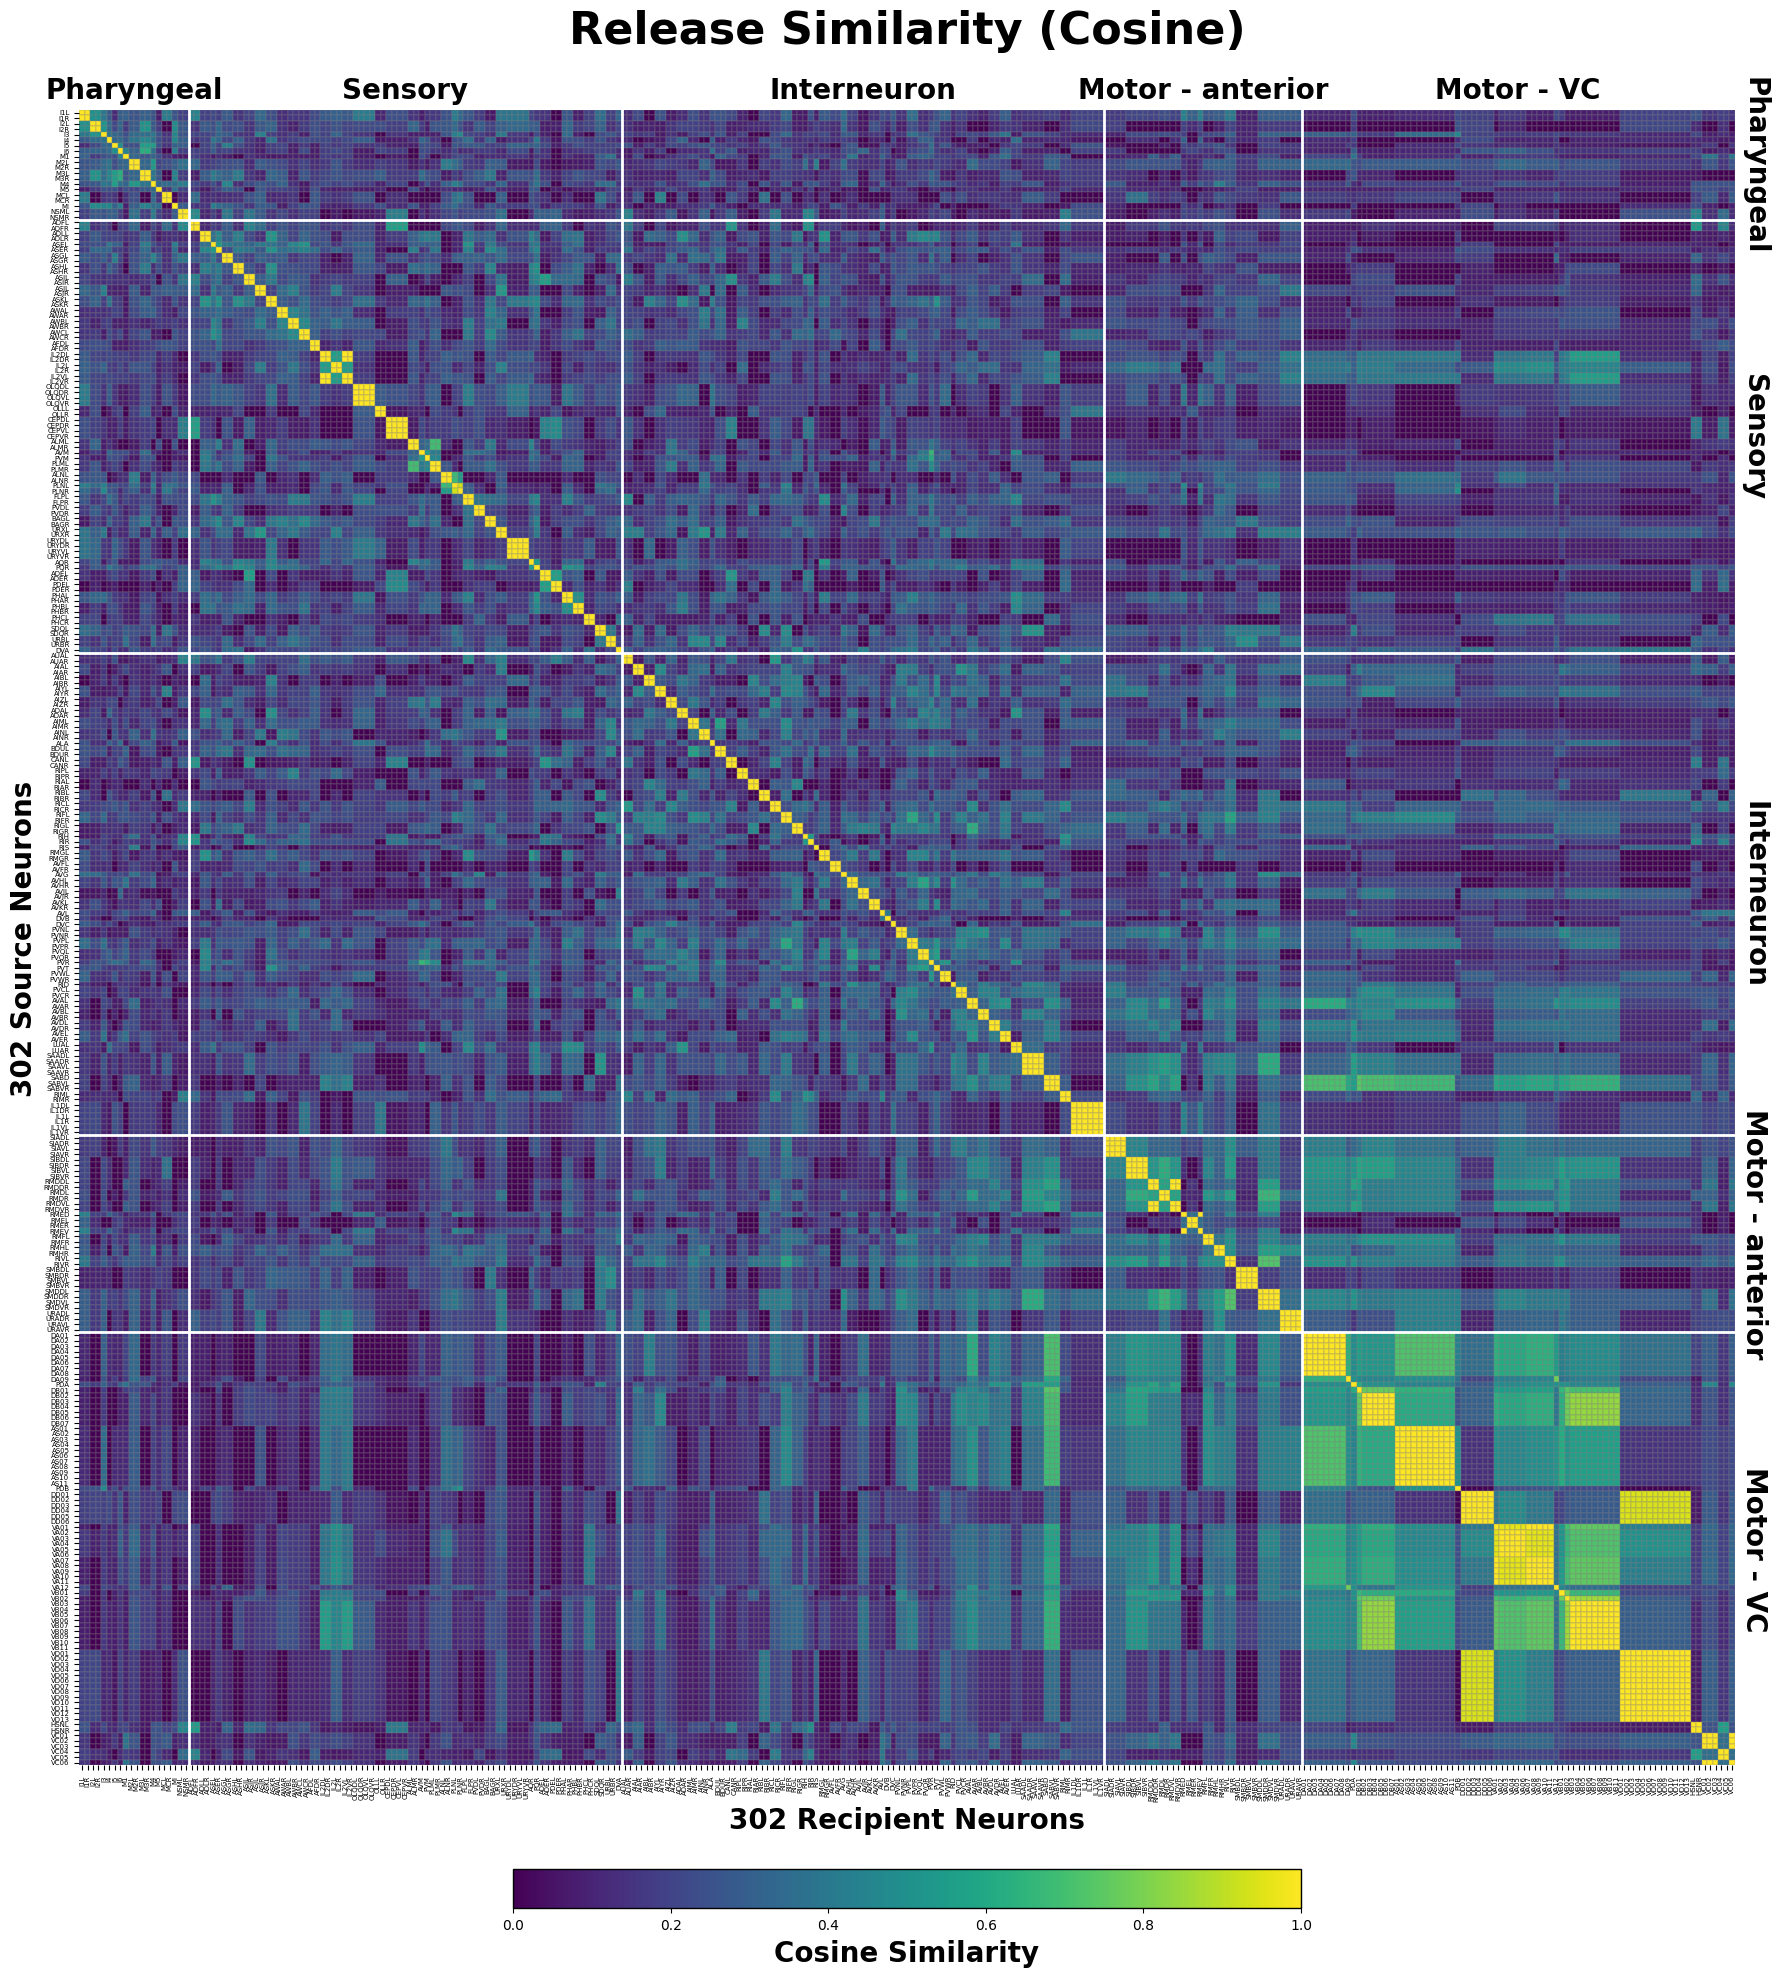

In [11]:
# Visualize release similarity with plot_similarity_matrix
fig = pu.plot_similarity_matrix(
    release_sim,
    title='Release Similarity (Cosine)',
    colormap_name='viridis',
    colorbar_label='Cosine Similarity'
)

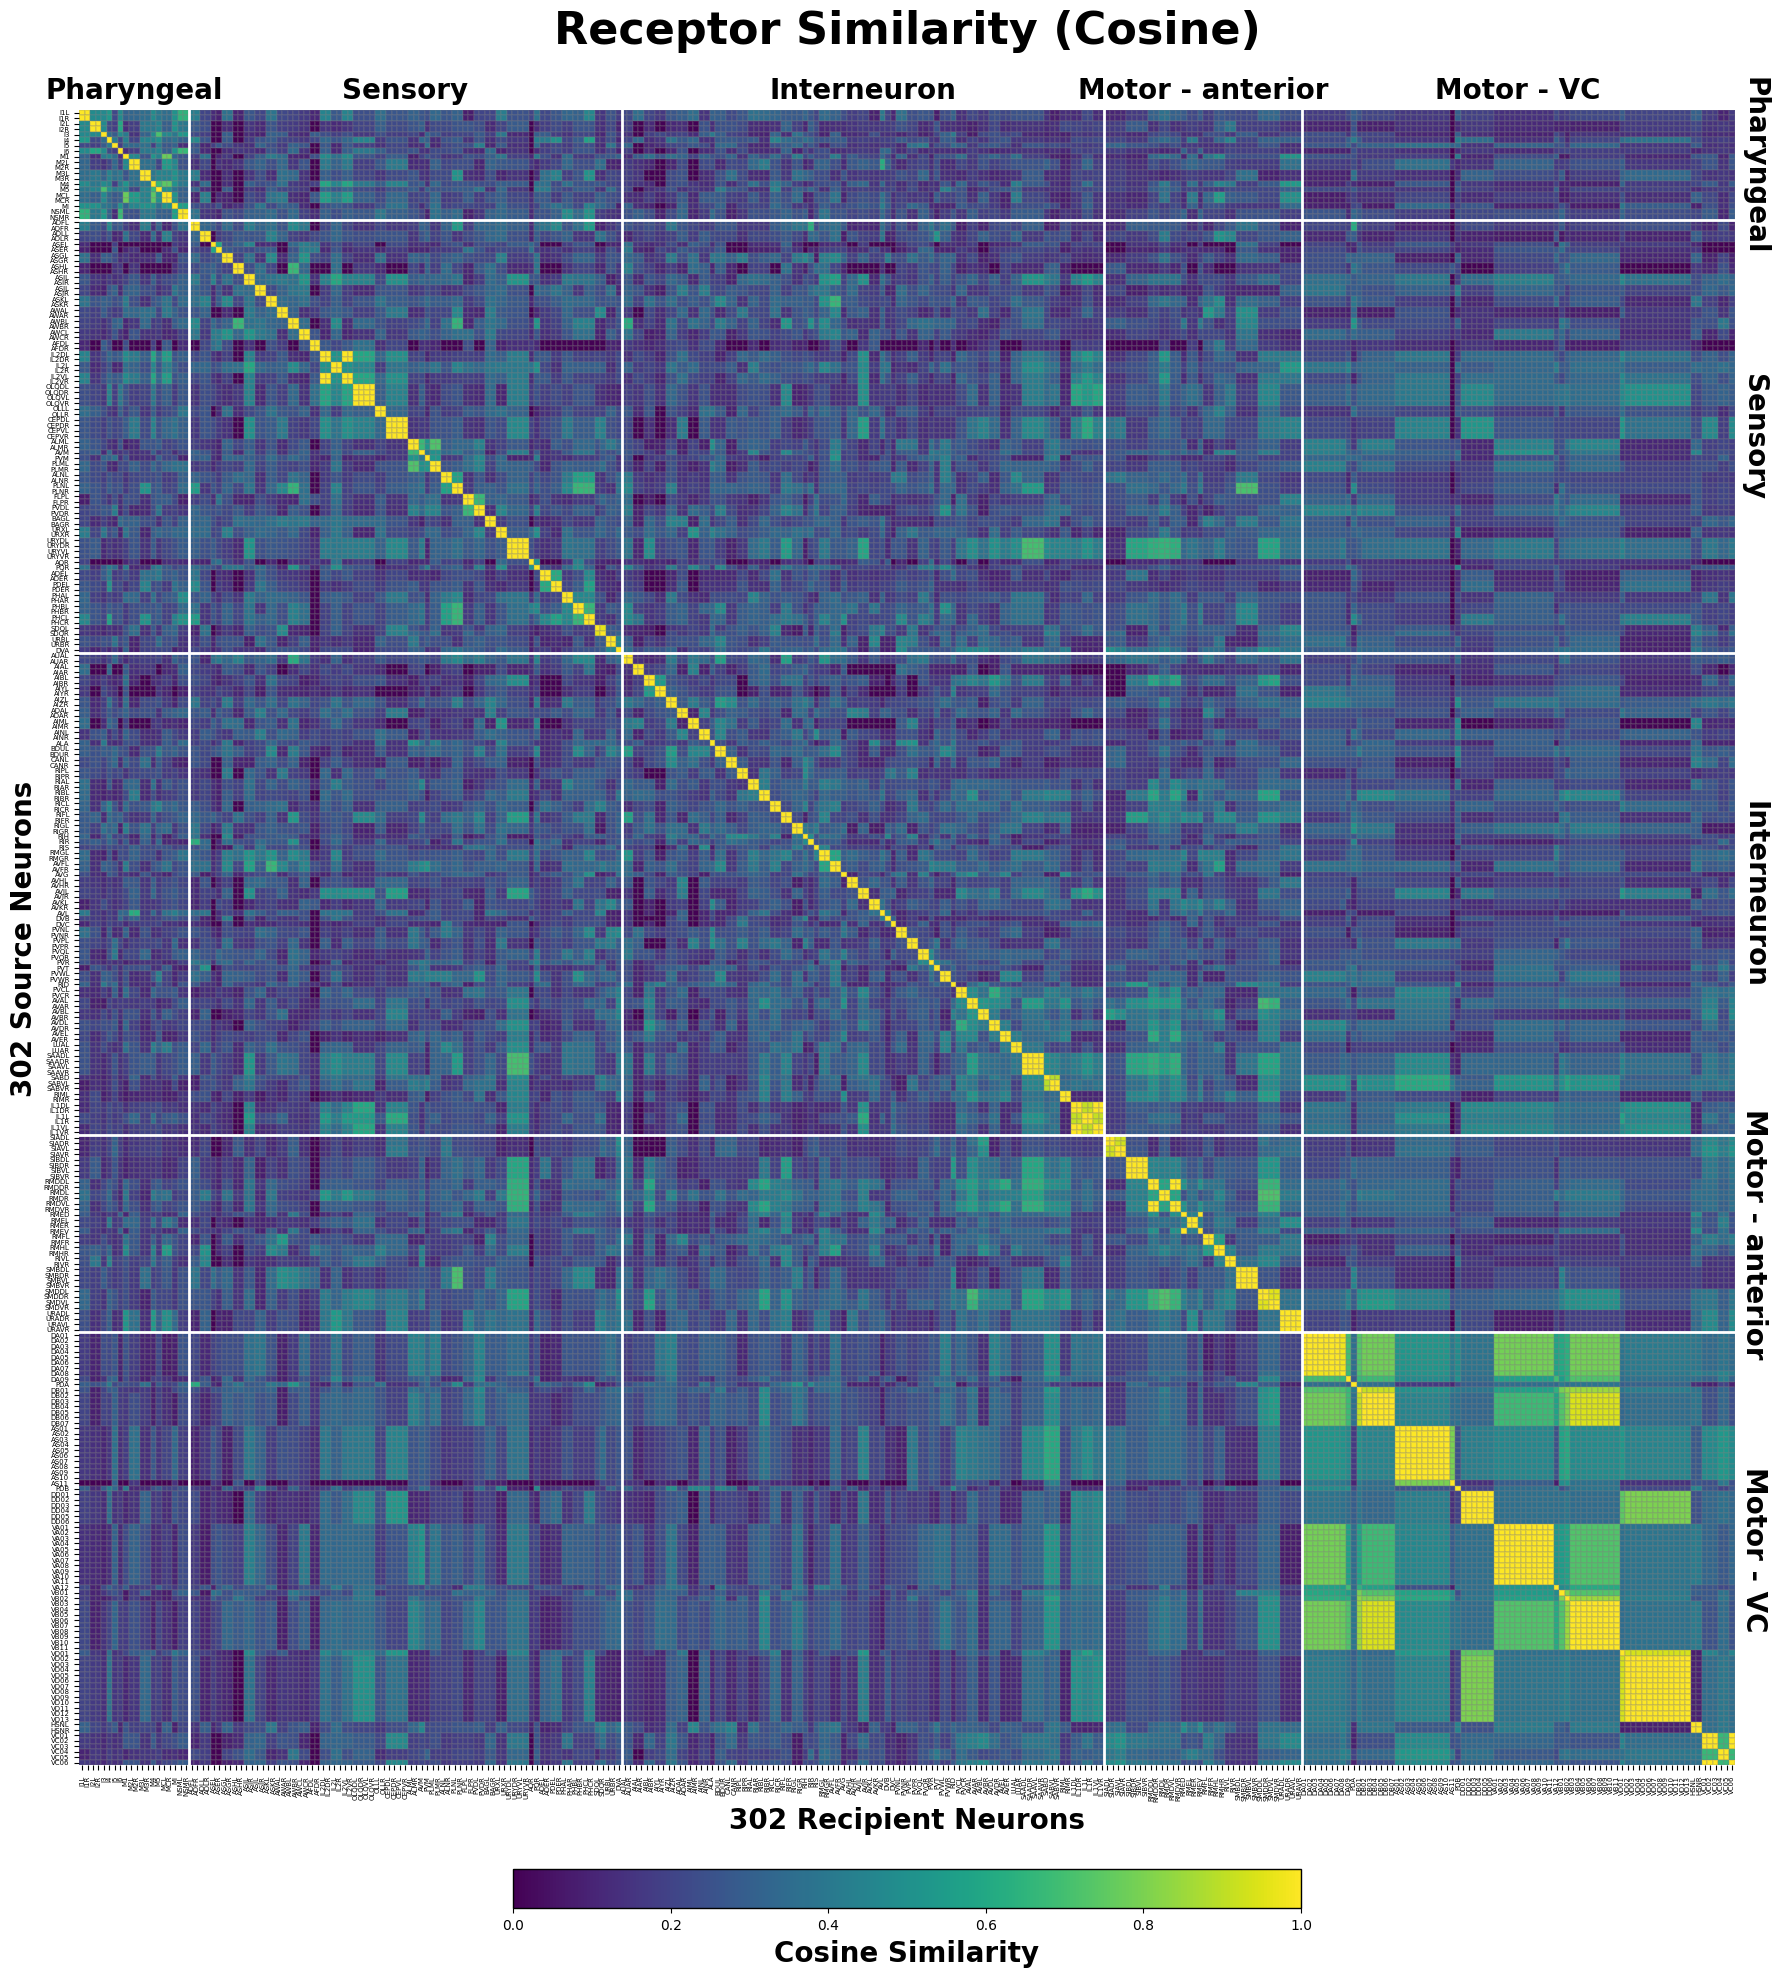

In [12]:
# Visualize receptor similarity with plot_similarity_matrix
fig = pu.plot_similarity_matrix(
    receptor_sim,
    title='Receptor Similarity (Cosine)',
    colormap_name='viridis',
    colorbar_label='Cosine Similarity'
)

## 7. Analyze Similarity Distributions

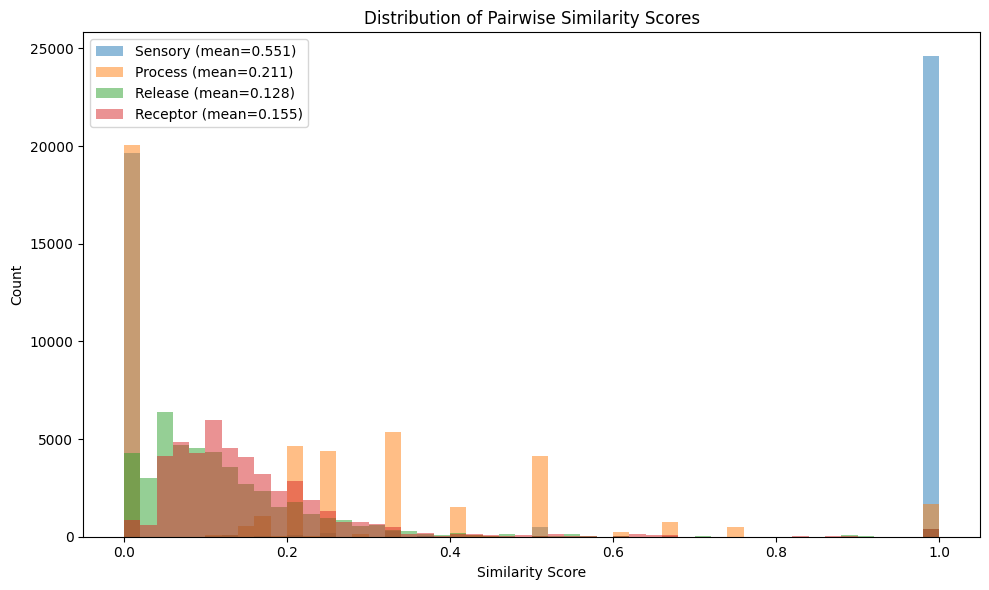

In [14]:
# Get upper triangle values (excluding diagonal)
def get_upper_triangle(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return matrix.values[mask]

fig, ax = plt.subplots(figsize=(10, 6))

for label, sim_matrix in [
    ('Sensory', sensory_sim),
    ('Process', process_sim),
    ('Release', release_sim),
    ('Receptor', receptor_sim)
]:
    values = get_upper_triangle(sim_matrix)
    values = values[~np.isnan(values)]  # Remove NaN
    ax.hist(values, bins=50, alpha=0.5, label=f"{label} (mean={values.mean():.3f})")

ax.set_xlabel('Similarity Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pairwise Similarity Scores')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Identify Highly Similar Neuron Groups

In [14]:
# Find all pairs with high similarity (> 0.8) in each dimension
def find_high_similarity_pairs(sim_matrix, threshold=0.8):
    pairs = []
    neurons = sim_matrix.index.tolist()
    for i, n1 in enumerate(neurons):
        for n2 in neurons[i+1:]:
            sim = sim_matrix.loc[n1, n2]
            if sim >= threshold:
                pairs.append((n1, n2, sim))
    return sorted(pairs, key=lambda x: -x[2])

print("Neuron pairs with high receptor similarity (>0.8):")
high_receptor_pairs = find_high_similarity_pairs(receptor_sim, 0.8)
for n1, n2, sim in high_receptor_pairs:
    print(f"  {n1:6s} - {n2:6s}: {sim:.4f}")

Neuron pairs with high receptor similarity (>0.8):
  M2L    - M2R   : 1.0000
  ASGL   - ASGR  : 1.0000
  ASKL   - ASKR  : 1.0000
  AWAL   - AWAR  : 1.0000
  AFDL   - AFDR  : 1.0000
  ALML   - ALMR  : 1.0000
  PLNL   - PLNR  : 1.0000
  FLPL   - FLPR  : 1.0000
  ADEL   - ADER  : 1.0000
  PHAL   - PHAR  : 1.0000
  PHBL   - PHBR  : 1.0000
  PHCL   - PHCR  : 1.0000
  URBL   - URBR  : 1.0000
  AUAL   - AUAR  : 1.0000
  ADAL   - ADAR  : 1.0000
  AINL   - AINR  : 1.0000
  BDUL   - BDUR  : 1.0000
  CANL   - CANR  : 1.0000
  RIAL   - RIAR  : 1.0000
  RIGL   - RIGR  : 1.0000
  AVFL   - AVFR  : 1.0000
  PVNL   - PVNR  : 1.0000
  PVWL   - PVWR  : 1.0000
  AVAL   - AVAR  : 1.0000
  SABVL  - SABVR : 1.0000
  IL1L   - IL1R  : 1.0000
  SIAVL  - SIAVR : 1.0000
  RMDDL  - RMDDR : 1.0000
  RMDDL  - RMDVL : 1.0000
  RMDDL  - RMDVR : 1.0000
  RMDDR  - RMDVL : 1.0000
  RMDDR  - RMDVR : 1.0000
  RMDVL  - RMDVR : 1.0000
  RMEL   - RMER  : 1.0000
  SMBDL  - SMBDR : 1.0000
  SMBDL  - SMBVL : 1.0000
  SMBDL  - SM

## 9. Export Results

In [ ]:
# Save comparison results
comparison_df.to_csv('../connectomes/similarity/neuron_pair_comparison.csv')
print("Saved neuron pair comparison to: connectomes/similarity/neuron_pair_comparison.csv")